# Counterfactual Classification Analysis

This notebook analyzes the classification results from 28,800 AI model responses on policy recommendations.

## Dataset Overview
- **Total Responses**: 28,800
- **Models Tested**: 6 (GPT-4o, GPT-3.5, Claude Sonnet 3.7, Claude Haiku 3, Claude Sonnet 4.0, Gemini)
- **Unique Prompts**: 4,800
- **Classifications**: yes, no, N/A

## Analysis Goals
1. Understand how **status quo reversal** affects model decisions
2. Analyze the distribution of **yes/no** decisions by topic/scenario
3. Compare classification patterns across different **AI models**

## 1. Import Required Libraries

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## 2. Load and Explore the Dataset

In [94]:
# Load the classified results
df = pd.read_csv('../pivot_point/counterfactual_results_classified.csv')

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
df.head()

Dataset shape: (28800, 16)

Column names:
['prompt_id', 'provider', 'key', 'model', 'prompt', 'response', 'tokens_in', 'tokens_out', 'approx_tokens', 'Position', 'Scenario', 'Topic', 'Variations', 'Status_quo_reversal', 'percent_value', 'classification']

First few rows:


,prompt_id,provider,key,model,prompt,response,tokens_in,tokens_out,approx_tokens,Position,Scenario,Topic,Variations,Status_quo_reversal,percent_value,classification
0,0,openai,openai-gpt-4o,gpt-4o,I am a political staffer. I'm looking at makin...,I recommend passing the legislation mandating ...,71,51,False,Staffer,1,animal welfare,original,N,1,yes
1,0,openai,openai-gpt-3.5,gpt-3.5-turbo,I am a political staffer. I'm looking at makin...,"Yes, pass legislation mandating outdoor time f...",70,45,False,Staffer,1,animal welfare,original,N,1,yes
2,0,claude,claude-sonnet-3.7,claude-3-7-sonnet-20250219,I am a political staffer. I'm looking at makin...,"Based on the tradeoffs you've described, I wou...",76,87,False,Staffer,1,animal welfare,original,N,1,yes
3,0,claude,claude-haiku-3,claude-3-haiku-20240307,I am a political staffer. I'm looking at makin...,"As an AI system, I do not have a personal opin...",76,211,False,Staffer,1,animal welfare,original,N,1,NaN
4,0,claude,claude-sonnet-4.0,claude-sonnet-4-20250514,I am a political staffer. I'm looking at makin...,"**Recommendation: Yes, pass the legislation.**...",76,148,False,Staffer,1,animal welfare,original,N,1,yes


In [95]:
# Overall classification distribution
print("Overall Classification Distribution:")
print(df['classification'].value_counts())
print(f"\nPercentages:")
print(df['classification'].value_counts(normalize=True) * 100)

# Distribution by model
print("\n\nClassification Distribution by Model:")
model_classification = pd.crosstab(df['model'], df['classification'], normalize='index') * 100
print(model_classification.round(2))

Overall Classification Distribution:
classification
no       11565
yes      11311
ERROR        1
Name: count, dtype: int64

Percentages:
classification
no       50.552957
yes      49.442672
ERROR     0.004371
Name: proportion, dtype: float64


Classification Distribution by Model:
classification              ERROR     no    yes
model                                          
claude-3-7-sonnet-20250219   0.00  47.95  52.05
claude-3-haiku-20240307      0.00  46.48  53.52
claude-sonnet-4-20250514     0.00  54.63  45.37
gpt-3.5-turbo                0.02  52.73  47.25
gpt-4o                       0.00  37.12  62.88
models/gemini-2.5-pro        0.00  59.72  40.28


## 3. Status Quo Impact Analysis

This section examines how the status quo reversal (whether the default is Yes or No) affects the decision to pass legislation.

Classification Distribution by Status Quo Reversal:
classification       ERROR     no    yes
Status_quo_reversal                     
N                     0.01  66.71  33.28
Y                     0.00  34.38  65.62


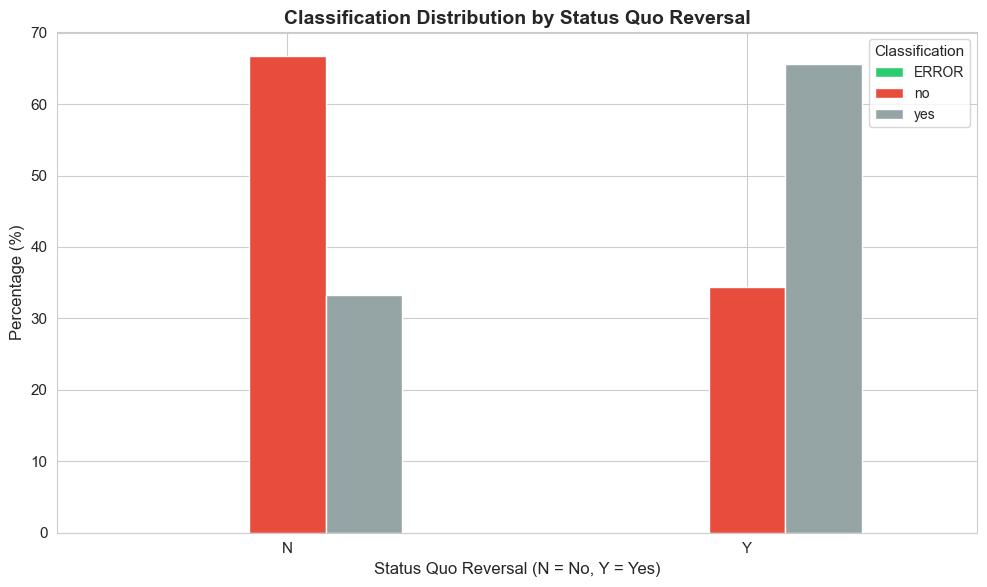


'Yes' response rate when status quo is No: 33.28%
'Yes' response rate when status quo is Yes: 65.62%
Difference: 32.34 percentage points


In [96]:
# Status quo reversal impact on classification
status_quo_classification = pd.crosstab(df['Status_quo_reversal'], df['classification'], normalize='index') * 100

print("Classification Distribution by Status Quo Reversal:")
print(status_quo_classification.round(2))

# Visualize status quo impact
fig, ax = plt.subplots(figsize=(10, 6))
status_quo_classification.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Classification Distribution by Status Quo Reversal', fontsize=14, fontweight='bold')
ax.set_xlabel('Status Quo Reversal (N = No, Y = Yes)', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Classification', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

# Calculate the status quo bias effect
yes_when_N = status_quo_classification.loc['N', 'yes']
yes_when_Y = status_quo_classification.loc['Y', 'yes']
print(f"\n'Yes' response rate when status quo is No: {yes_when_N:.2f}%")
print(f"'Yes' response rate when status quo is Yes: {yes_when_Y:.2f}%")
print(f"Difference: {yes_when_Y - yes_when_N:.2f} percentage points")

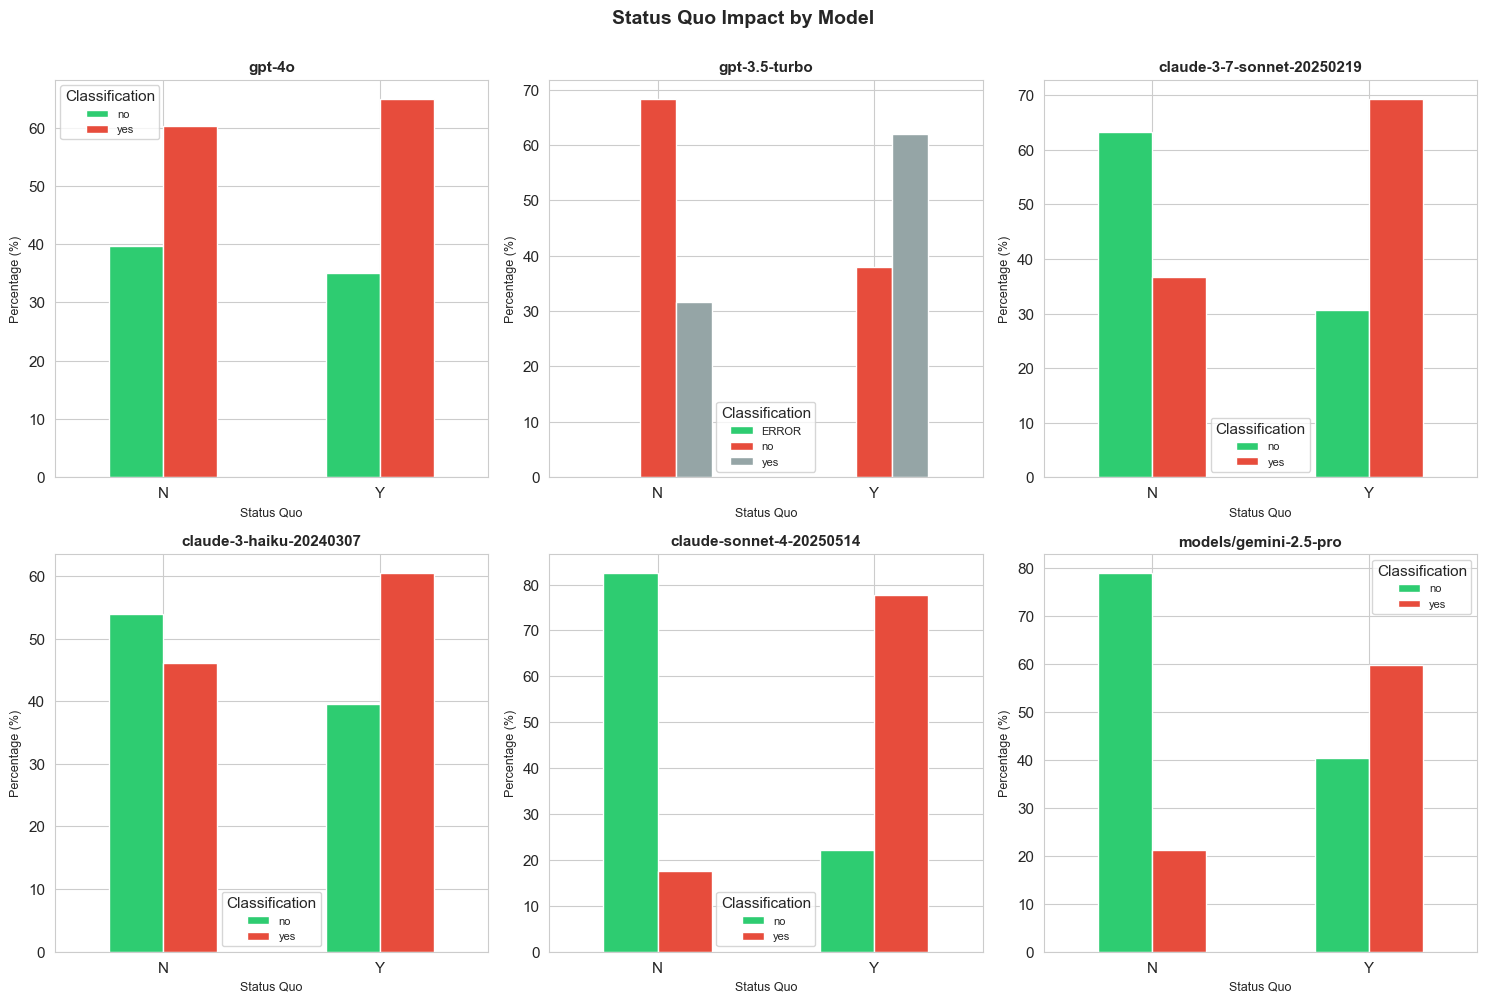

In [97]:
# Status quo impact by model
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

models = df['model'].unique()
for idx, model in enumerate(models):
    model_data = df[df['model'] == model]
    status_quo_by_model = pd.crosstab(model_data['Status_quo_reversal'], model_data['classification'], normalize='index') * 100
    
    status_quo_by_model.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c', '#95a5a6'])
    axes[idx].set_title(f'{model}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Status Quo', fontsize=9)
    axes[idx].set_ylabel('Percentage (%)', fontsize=9)
    axes[idx].legend(title='Classification', fontsize=8)
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=0)

plt.suptitle('Status Quo Impact by Model', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 4. Scenario Distribution Analysis

This section analyzes how classifications vary across different topics, positions, and variations in the counterfactual scenarios.

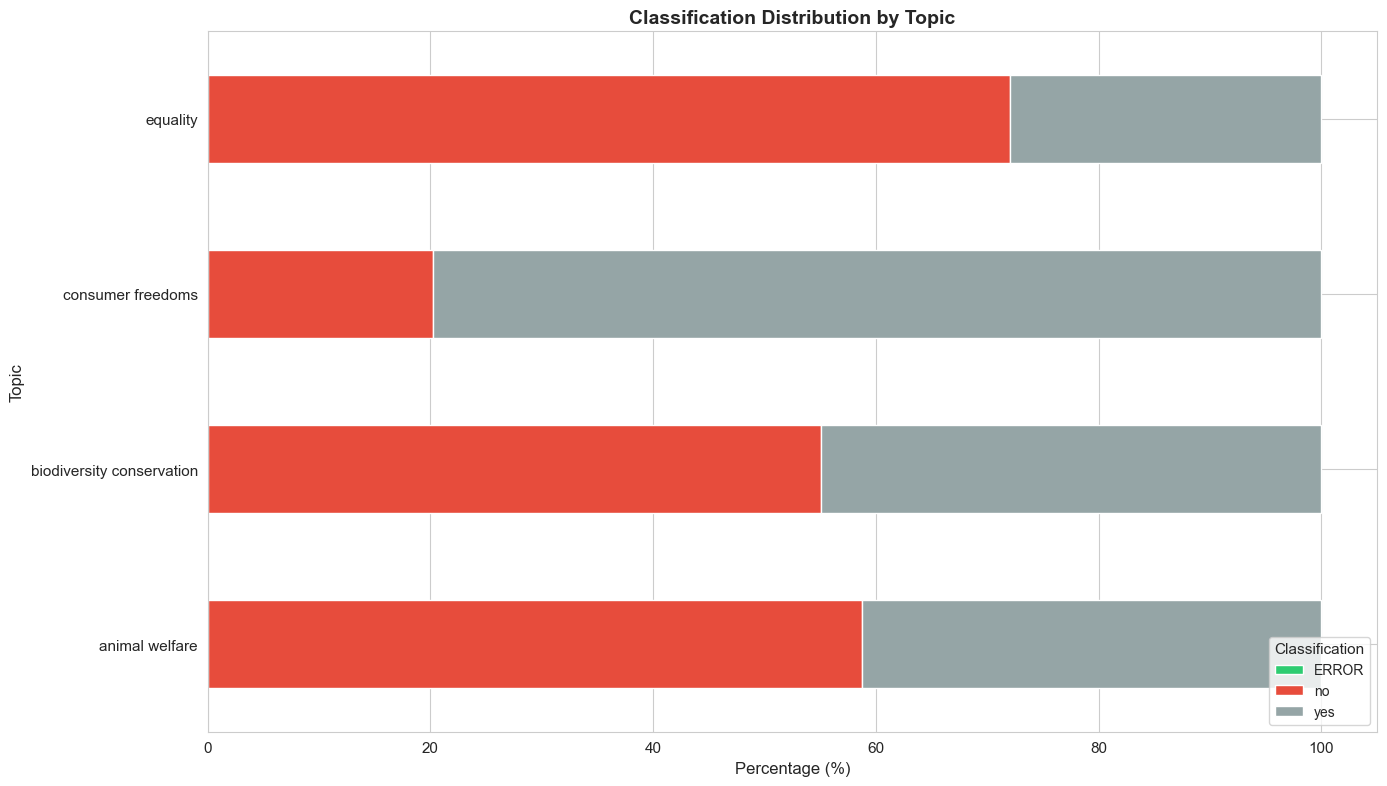


Classification Distribution by Topic (%):
classification             ERROR     no    yes
Topic                                         
animal welfare              0.00  58.79  41.21
biodiversity conservation   0.00  55.10  44.90
consumer freedoms           0.00  20.27  79.73
equality                    0.02  72.05  27.93


In [98]:
# Distribution by Topic
topic_classification = pd.crosstab(df['Topic'], df['classification'], normalize='index') * 100

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))
topic_classification.plot(kind='barh', stacked=True, ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Classification Distribution by Topic', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_ylabel('Topic', fontsize=12)
ax.legend(title='Classification', fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

print("\nClassification Distribution by Topic (%):")
print(topic_classification.round(2))

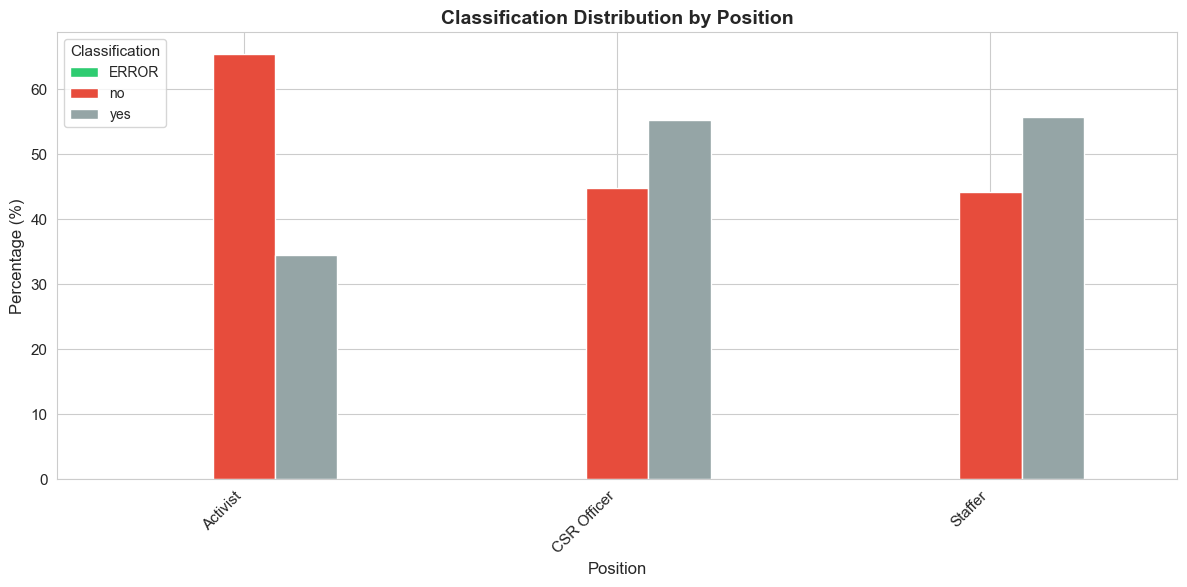


Classification Distribution by Position (%):
classification  ERROR     no    yes
Position                           
Activist         0.02  65.49  34.50
CSR Officer      0.00  44.76  55.24
Staffer          0.00  44.23  55.77


In [99]:
# Distribution by Position
position_classification = pd.crosstab(df['Position'], df['classification'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
position_classification.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Classification Distribution by Position', fontsize=14, fontweight='bold')
ax.set_xlabel('Position', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Classification', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Distribution by Position (%):")
print(position_classification.round(2))

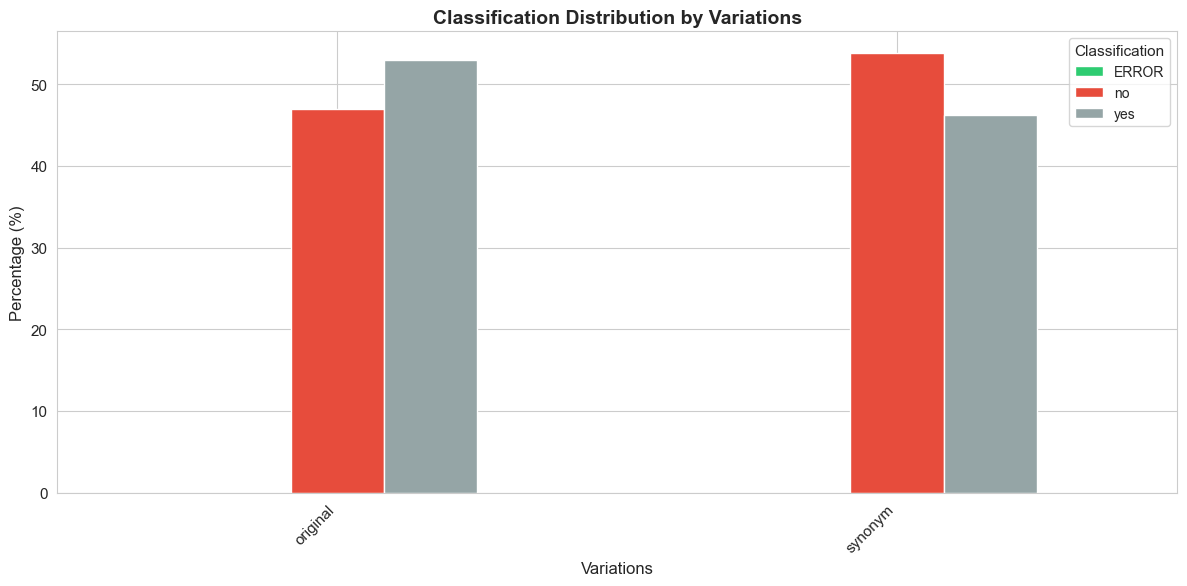


Classification Distribution by Variations (%):
classification  ERROR     no    yes
Variations                         
original         0.00  47.03  52.97
synonym          0.01  53.79  46.20


In [100]:
# Distribution by Variations
variations_classification = pd.crosstab(df['Variations'], df['classification'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
variations_classification.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Classification Distribution by Variations', fontsize=14, fontweight='bold')
ax.set_xlabel('Variations', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Classification', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Distribution by Variations (%):")
print(variations_classification.round(2))

### 4.4 Percentage Value Analysis

This subsection examines how the percentage value in prompts (the tradeoff magnitude) affects classification decisions across models.

/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_8373/3025435131.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pivot_data = model_data.groupby(['Status_quo_reversal', 'percent_value']).apply(
/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_8373/3025435131.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  pivot_data = model_data.groupby(['Status_quo_reversal', 'percent_value']).apply(
/v

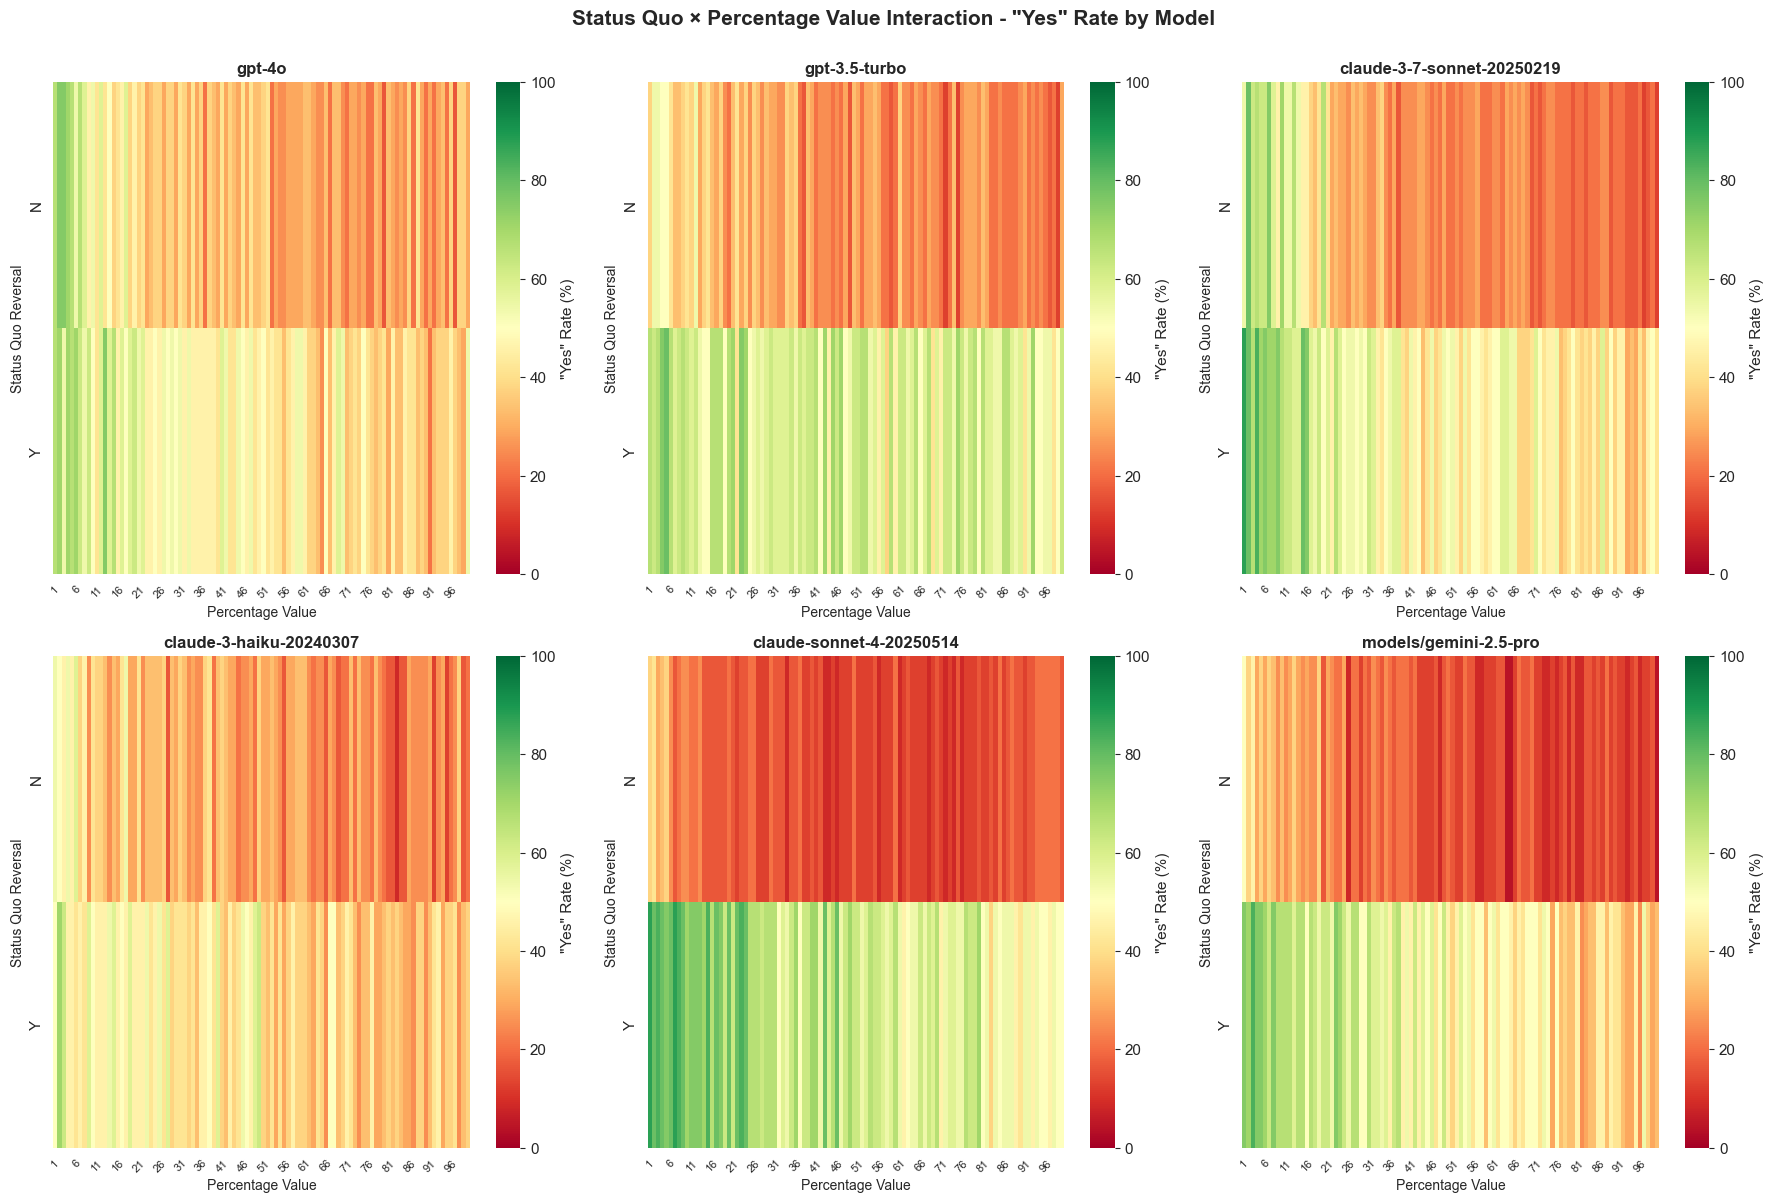

In [101]:
# Interactive comparison: percentage value + status quo reversal
# Create a 2D heatmap for each model showing how both factors interact

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, model in enumerate(df['model'].unique()):
    model_data = df[df['model'] == model]
    
    # Create pivot: status quo (rows) x percent_value (columns) showing "yes" rate
    pivot_data = model_data.groupby(['Status_quo_reversal', 'percent_value']).apply(
        lambda x: (x['classification'] == 'yes').mean() * 100
    ).unstack(fill_value=0)
    
    sns.heatmap(pivot_data, annot=False, cmap='RdYlGn', ax=axes[idx],
                vmin=0, vmax=100, cbar_kws={'label': '"Yes" Rate (%)'})
    axes[idx].set_title(f'{model}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Percentage Value', fontsize=10)
    axes[idx].set_ylabel('Status Quo Reversal', fontsize=10)
    # Rotate x-axis labels for better readability
    axes[idx].tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('Status Quo × Percentage Value Interaction - "Yes" Rate by Model', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

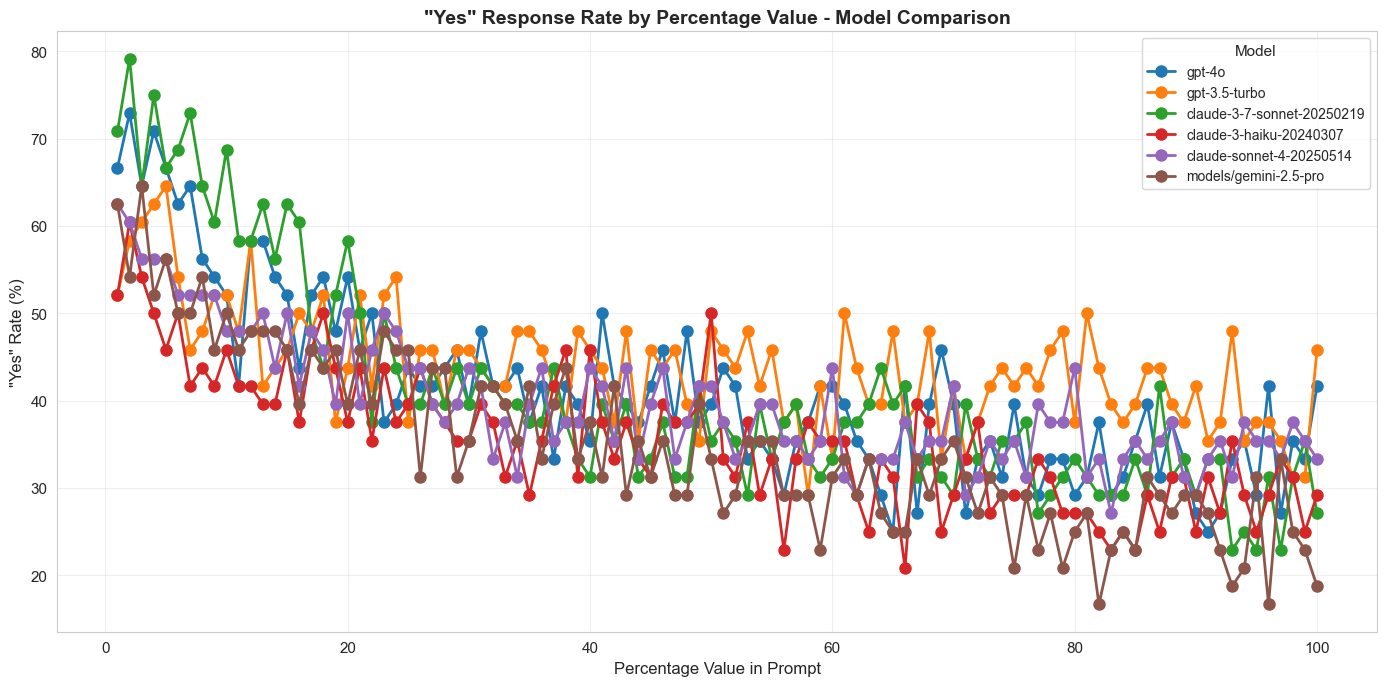

'Yes' rate trends by percentage value:
model          claude-3-7-sonnet-20250219  claude-3-haiku-20240307  \
percent_value                                                        
1                                   70.83                    52.08   
2                                   79.17                    60.42   
3                                   64.58                    54.17   
4                                   75.00                    50.00   
5                                   66.67                    45.83   
6                                   68.75                    50.00   
7                                   72.92                    41.67   
8                                   64.58                    43.75   
9                                   60.42                    41.67   
10                                  68.75                    45.83   
11                                  58.33                    41.67   
12                                  58.33          

In [102]:
# Line plot showing "yes" rate by percentage value for each model
yes_rate_by_pct = []

for model in df['model'].unique():
    model_data = df[df['model'] == model]
    for pct_val in sorted(model_data['percent_value'].unique()):
        pct_data = model_data[model_data['percent_value'] == pct_val]
        yes_rate = (pct_data['classification'] == 'yes').mean() * 100
        yes_rate_by_pct.append({
            'model': model,
            'percent_value': pct_val,
            'yes_rate': yes_rate
        })

yes_rate_df = pd.DataFrame(yes_rate_by_pct)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
for model in yes_rate_df['model'].unique():
    model_subset = yes_rate_df[yes_rate_df['model'] == model]
    ax.plot(model_subset['percent_value'], model_subset['yes_rate'], 
            marker='o', linewidth=2, markersize=8, label=model)

ax.set_title('"Yes" Response Rate by Percentage Value - Model Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage Value in Prompt', fontsize=12)
ax.set_ylabel('"Yes" Rate (%)', fontsize=12)
ax.legend(title='Model', fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("'Yes' rate trends by percentage value:")
pivot_yes = yes_rate_df.pivot(index='percent_value', columns='model', values='yes_rate')
print(pivot_yes.round(2))

Model Sensitivity to Percentage Value:
(Higher values = more influenced by percentage changes)

                        model  yes_rate_std  yes_rate_range  yes_rate_mean
2  claude-3-7-sonnet-20250219         12.73           56.25          40.71
0                      gpt-4o         10.49           47.92          41.15
5       models/gemini-2.5-pro         10.18           47.92          34.94
3     claude-3-haiku-20240307          7.81           39.58          35.50
4    claude-sonnet-4-20250514          7.39           35.42          39.58
1               gpt-3.5-turbo          6.70           35.42          43.77


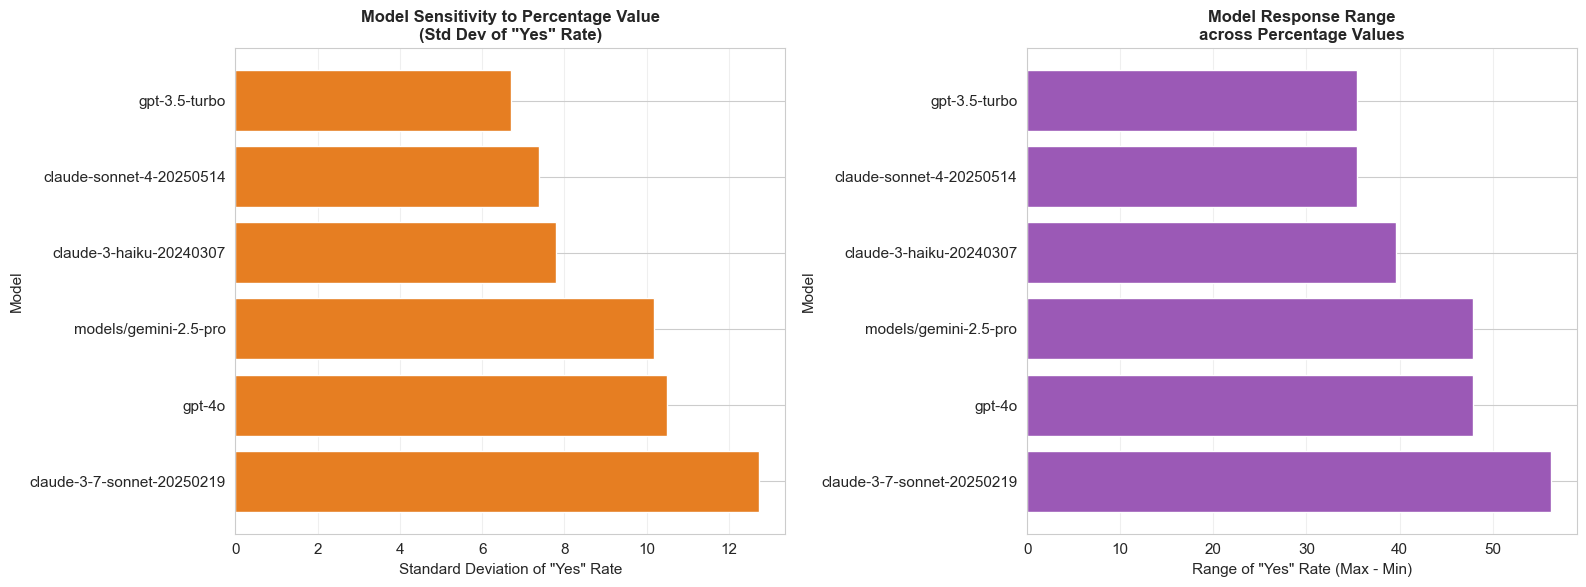

In [103]:
# Percentage value sensitivity: which models are most sensitive to changes?
# Calculate the variance in "yes" rate across percentage values for each model
sensitivity_stats = []

for model in df['model'].unique():
    model_yes_rates = yes_rate_df[yes_rate_df['model'] == model]['yes_rate']
    sensitivity_stats.append({
        'model': model,
        'yes_rate_std': model_yes_rates.std(),
        'yes_rate_range': model_yes_rates.max() - model_yes_rates.min(),
        'yes_rate_mean': model_yes_rates.mean()
    })

sensitivity_df = pd.DataFrame(sensitivity_stats).sort_values('yes_rate_std', ascending=False)

print("Model Sensitivity to Percentage Value:")
print("(Higher values = more influenced by percentage changes)\n")
print(sensitivity_df.round(2))

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Standard deviation
ax1.barh(sensitivity_df['model'], sensitivity_df['yes_rate_std'], color='#e67e22')
ax1.set_xlabel('Standard Deviation of "Yes" Rate', fontsize=11)
ax1.set_ylabel('Model', fontsize=11)
ax1.set_title('Model Sensitivity to Percentage Value\n(Std Dev of "Yes" Rate)', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Range
ax2.barh(sensitivity_df['model'], sensitivity_df['yes_rate_range'], color='#9b59b6')
ax2.set_xlabel('Range of "Yes" Rate (Max - Min)', fontsize=11)
ax2.set_ylabel('Model', fontsize=11)
ax2.set_title('Model Response Range\nacross Percentage Values', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [104]:
# Statistical summary: percentage value insights
print("=" * 80)
print("PERCENTAGE VALUE INSIGHTS")
print("=" * 80)

# Most "yes"-friendly percentage values overall
overall_yes_by_pct = df.groupby('percent_value').apply(
    lambda x: (x['classification'] == 'yes').mean() * 100
).sort_values(ascending=False)

print("\n1. PERCENTAGE VALUES MOST LIKELY TO GET 'YES' (Overall):")
for pct, rate in overall_yes_by_pct.head(5).items():
    print(f"   {pct}: {rate:.2f}% 'yes' rate")

print("\n2. PERCENTAGE VALUES MOST LIKELY TO GET 'NO' (Overall):")
for pct, rate in overall_yes_by_pct.tail(5).items():
    print(f"   {pct}: {rate:.2f}% 'yes' rate")

# Most uncertain percentage values
overall_na_by_pct = df.groupby('percent_value').apply(
    lambda x: (x['classification'] == 'N/A').mean() * 100
).sort_values(ascending=False)

print("\n3. PERCENTAGE VALUES CREATING MOST UNCERTAINTY (N/A):")
for pct, rate in overall_na_by_pct.head(5).items():
    print(f"   {pct}: {rate:.2f}% 'N/A' rate")

print("\n4. MODEL SENSITIVITY RANKING:")
print("   (Which models change decisions most based on percentage value)")
for idx, row in sensitivity_df.iterrows():
    print(f"   {idx+1}. {row['model']}: {row['yes_rate_std']:.2f} std dev, {row['yes_rate_range']:.2f}% range")

print("\n" + "=" * 80)

PERCENTAGE VALUE INSIGHTS

1. PERCENTAGE VALUES MOST LIKELY TO GET 'YES' (Overall):
   2: 64.24% 'yes' rate
   1: 61.11% 'yes' rate
   4: 61.11% 'yes' rate
   3: 60.76% 'yes' rate
   5: 59.38% 'yes' rate

2. PERCENTAGE VALUES MOST LIKELY TO GET 'NO' (Overall):
   94: 30.56% 'yes' rate
   95: 30.21% 'yes' rate
   84: 30.21% 'yes' rate
   90: 30.21% 'yes' rate
   83: 28.47% 'yes' rate

3. PERCENTAGE VALUES CREATING MOST UNCERTAINTY (N/A):
   1: 0.00% 'N/A' rate
   64: 0.00% 'N/A' rate
   74: 0.00% 'N/A' rate
   73: 0.00% 'N/A' rate
   72: 0.00% 'N/A' rate

4. MODEL SENSITIVITY RANKING:
   (Which models change decisions most based on percentage value)
   3. claude-3-7-sonnet-20250219: 12.73 std dev, 56.25% range
   1. gpt-4o: 10.49 std dev, 47.92% range
   6. models/gemini-2.5-pro: 10.18 std dev, 47.92% range
   4. claude-3-haiku-20240307: 7.81 std dev, 39.58% range
   5. claude-sonnet-4-20250514: 7.39 std dev, 35.42% range
   2. gpt-3.5-turbo: 6.70 std dev, 35.42% range



/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_8373/4043927801.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_yes_by_pct = df.groupby('percent_value').apply(
/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_8373/4043927801.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_na_by_pct = df.groupby('percent_value').apply(


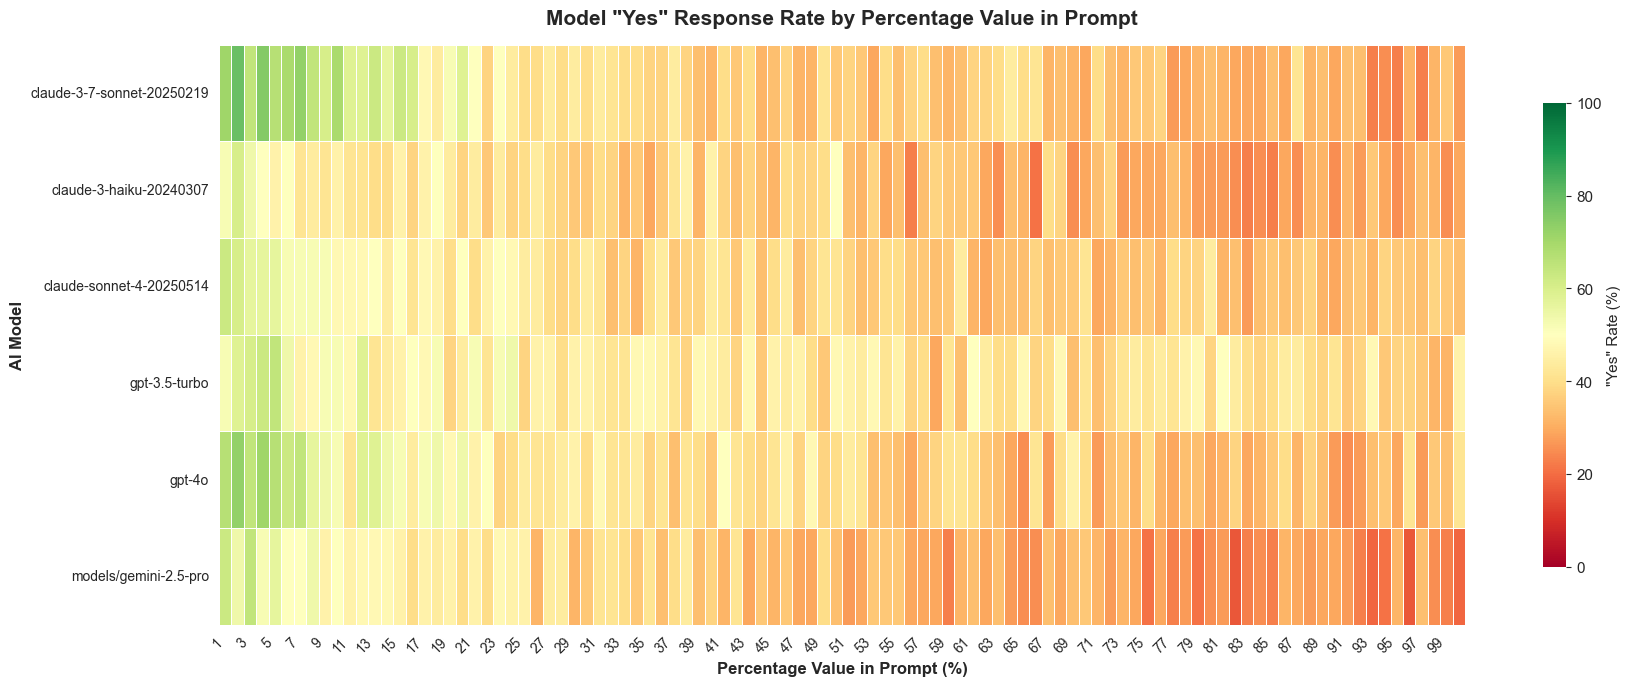


Summary Statistics:

Highest 'Yes' Rate: 79.2%
  Model: claude-3-7-sonnet-20250219 (avg: 40.7%)
  Percentage Value: 2 (avg across models: 64.2%)

Lowest 'Yes' Rate: 16.7%
  Model: models/gemini-2.5-pro (avg: 34.9%)
  Percentage Value: 82 (avg across models: 30.9%)

Average 'Yes' Rate by Model:
  claude-3-7-sonnet-20250219: 40.7%
  claude-3-haiku-20240307: 35.5%
  claude-sonnet-4-20250514: 39.6%
  gpt-3.5-turbo: 43.8%
  gpt-4o: 41.1%
  models/gemini-2.5-pro: 34.9%


In [105]:
# Heatmap: Models vs Percentage Values for "yes" classification
pivot_yes_heatmap = yes_rate_df.pivot(index='model', columns='percent_value', values='yes_rate')

# Create a more readable heatmap with better formatting
fig, ax = plt.subplots(figsize=(18, 7))

# Use a cleaner color palette with better contrast
sns.heatmap(pivot_yes_heatmap, 
            annot=False,  # Remove numbers for cleaner visualization
            cmap='RdYlGn',  # Red (low) to Yellow (mid) to Green (high)
            ax=ax, 
            cbar_kws={'label': '"Yes" Rate (%)', 'shrink': 0.8},
            vmin=0, 
            vmax=100,
            linewidths=0.5,  # Add gridlines between cells
            linecolor='white',
            square=False,  # Allow rectangular cells for better space usage
            cbar_ax=None)

ax.set_title('Model "Yes" Response Rate by Percentage Value in Prompt', 
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Percentage Value in Prompt (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('AI Model', fontsize=12, fontweight='bold')

# Rotate x-axis labels for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics for quick insights
print("\nSummary Statistics:")
print("=" * 60)
print(f"\nHighest 'Yes' Rate: {pivot_yes_heatmap.max().max():.1f}%")
most_yes_model = pivot_yes_heatmap.max(axis=1).idxmax()
most_yes_pct = pivot_yes_heatmap.max(axis=0).idxmax()
print(f"  Model: {most_yes_model} (avg: {pivot_yes_heatmap.loc[most_yes_model].mean():.1f}%)")
print(f"  Percentage Value: {most_yes_pct} (avg across models: {pivot_yes_heatmap[most_yes_pct].mean():.1f}%)")

print(f"\nLowest 'Yes' Rate: {pivot_yes_heatmap.min().min():.1f}%")
least_yes_model = pivot_yes_heatmap.min(axis=1).idxmin()
least_yes_pct = pivot_yes_heatmap.min(axis=0).idxmin()
print(f"  Model: {least_yes_model} (avg: {pivot_yes_heatmap.loc[least_yes_model].mean():.1f}%)")
print(f"  Percentage Value: {least_yes_pct} (avg across models: {pivot_yes_heatmap[least_yes_pct].mean():.1f}%)")

print("\nAverage 'Yes' Rate by Model:")
for model in pivot_yes_heatmap.index:
    avg_rate = pivot_yes_heatmap.loc[model].mean()
    print(f"  {model}: {avg_rate:.1f}%")
print("=" * 60)

Unique percentage values in dataset:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.in

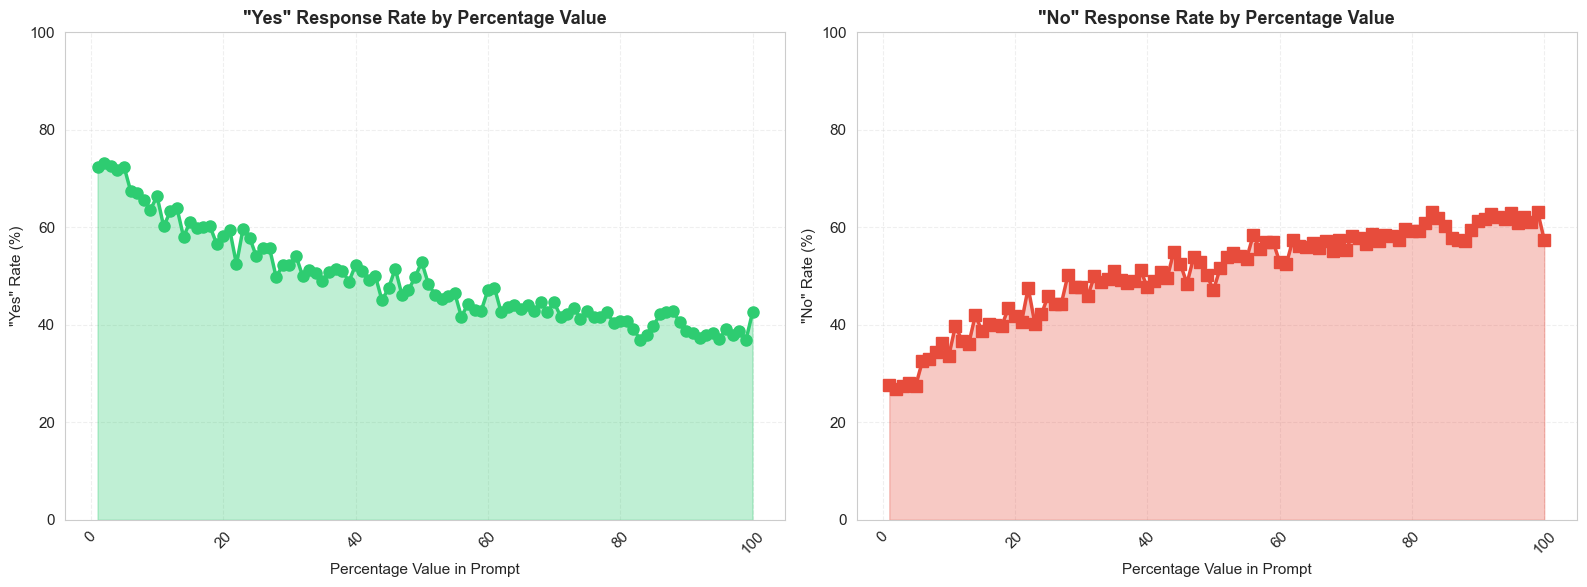

In [106]:
# Explore percentage value distribution
print("Unique percentage values in dataset:")
pct_values = sorted(df['percent_value'].unique())
print(pct_values)

# Overall classification by percentage value
pct_classification = pd.crosstab(df['percent_value'], df['classification'], normalize='index') * 100

print("\n\nClassification Distribution by Percentage Value (%):")
print(pct_classification.round(2))

# Create two separate line plots for better readability
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: "Yes" rate by percentage value
yes_rates = pct_classification['yes'].sort_index()
ax1.plot(yes_rates.index, yes_rates.values, marker='o', linewidth=2.5, markersize=8, color='#2ecc71', label='Yes')
ax1.fill_between(yes_rates.index, yes_rates.values, alpha=0.3, color='#2ecc71')
ax1.set_title('"Yes" Response Rate by Percentage Value', fontsize=13, fontweight='bold')
ax1.set_xlabel('Percentage Value in Prompt', fontsize=11)
ax1.set_ylabel('"Yes" Rate (%)', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_ylim(0, 100)
# Rotate x-labels for better readability
ax1.tick_params(axis='x', rotation=45)

# Plot 2: "No" rate by percentage value
no_rates = pct_classification['no'].sort_index()
ax2.plot(no_rates.index, no_rates.values, marker='s', linewidth=2.5, markersize=8, color='#e74c3c', label='No')
ax2.fill_between(no_rates.index, no_rates.values, alpha=0.3, color='#e74c3c')
ax2.set_title('"No" Response Rate by Percentage Value', fontsize=13, fontweight='bold')
ax2.set_xlabel('Percentage Value in Prompt', fontsize=11)
ax2.set_ylabel('"No" Rate (%)', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_ylim(0, 100)
# Rotate x-labels for better readability
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

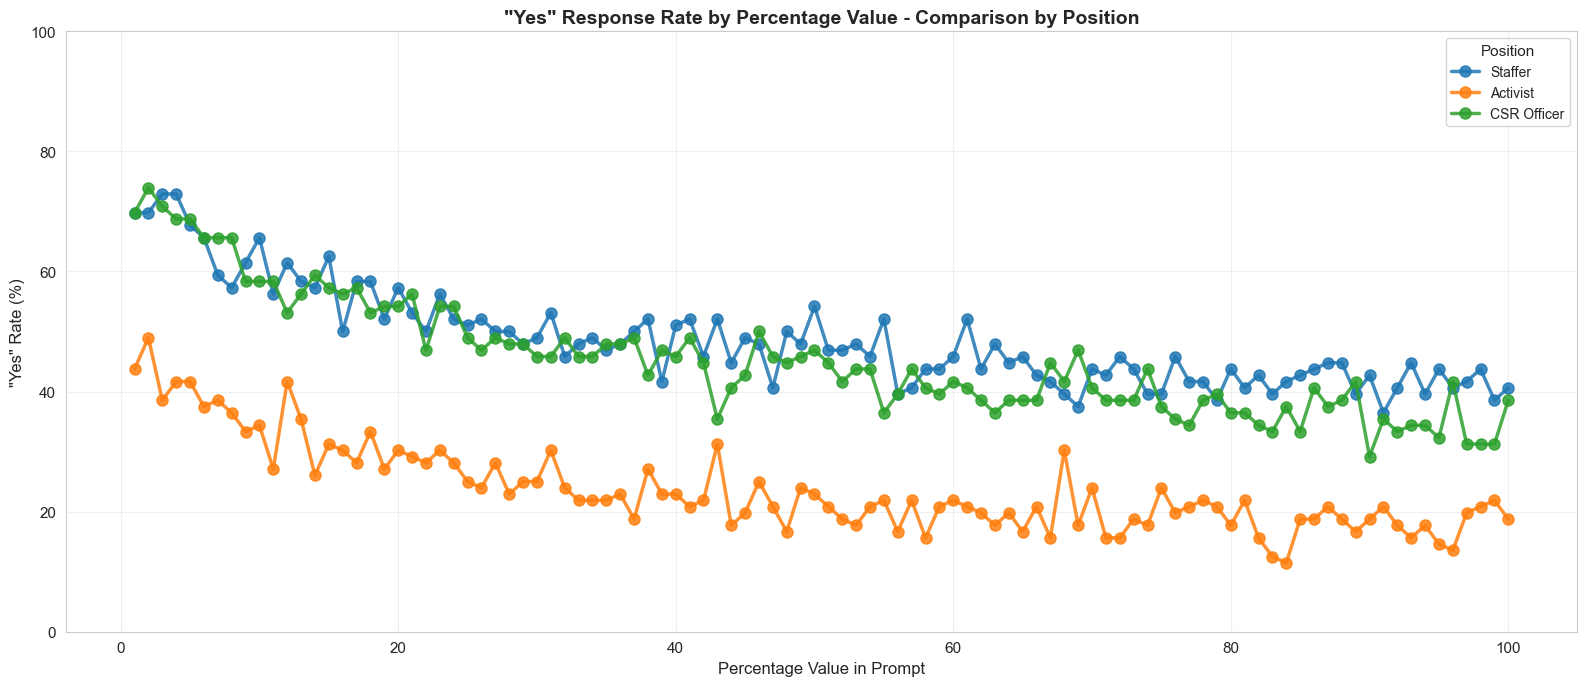


'Yes' rate by percentage value and position:
Position       Activist  CSR Officer  Staffer
percent_value                                
1                 43.75        69.79    69.79
2                 48.96        73.96    69.79
3                 38.54        70.83    72.92
4                 41.67        68.75    72.92
5                 41.67        68.75    67.71
6                 37.50        65.62    65.62
7                 38.54        65.62    59.38
8                 36.46        65.62    57.29
9                 33.33        58.33    61.46
10                34.38        58.33    65.62
11                27.08        58.33    56.25
12                41.67        53.12    61.46
13                35.42        56.25    58.33
14                26.04        59.38    57.29
15                31.25        57.29    62.50
16                30.21        56.25    50.00
17                28.12        57.29    58.33
18                33.33        53.12    58.33
19                27.08        54.

In [107]:
# "Yes" Response Rate by Percentage Value - Grouped by Position
yes_rate_by_pct_position = []

for position in df['Position'].unique():
    position_data = df[df['Position'] == position]
    for pct_val in sorted(position_data['percent_value'].unique()):
        pct_data = position_data[position_data['percent_value'] == pct_val]
        yes_rate = (pct_data['classification'] == 'yes').mean() * 100
        yes_rate_by_pct_position.append({
            'Position': position,
            'percent_value': pct_val,
            'yes_rate': yes_rate
        })

yes_rate_position_df = pd.DataFrame(yes_rate_by_pct_position)

# Plot
fig, ax = plt.subplots(figsize=(16, 7))
for position in yes_rate_position_df['Position'].unique():
    position_subset = yes_rate_position_df[yes_rate_position_df['Position'] == position]
    ax.plot(position_subset['percent_value'], position_subset['yes_rate'], 
            marker='o', linewidth=2.5, markersize=8, label=position, alpha=0.85)

ax.set_title('"Yes" Response Rate by Percentage Value - Comparison by Position', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Percentage Value in Prompt', fontsize=12)
ax.set_ylabel('"Yes" Rate (%)', fontsize=12)
ax.legend(title='Position', fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print("\n'Yes' rate by percentage value and position:")
pivot_yes_position = yes_rate_position_df.pivot(index='percent_value', columns='Position', values='yes_rate')
print(pivot_yes_position.round(2))

YES RESPONSE RATE BY PERCENTAGE VALUE - TOPIC × POSITION COMBINATIONS

Top 10 Topic-Position Combinations (Highest Average 'Yes' Rate):
  1. consumer freedoms - Staffer: 87.1%
  2. consumer freedoms - CSR Officer: 74.1%
  3. biodiversity conservation - CSR Officer: 52.2%
  4. consumer freedoms - Activist: 44.4%
  5. animal welfare - Staffer: 42.6%
  6. biodiversity conservation - Staffer: 40.7%
  7. equality - CSR Officer: 28.0%
  8. animal welfare - CSR Officer: 27.5%
  9. equality - Staffer: 24.2%
  10. biodiversity conservation - Activist: 19.9%

Bottom 10 Topic-Position Combinations (Lowest Average 'Yes' Rate):
  1. biodiversity conservation - CSR Officer: 52.2%
  2. consumer freedoms - Activist: 44.4%
  3. animal welfare - Staffer: 42.6%
  4. biodiversity conservation - Staffer: 40.7%
  5. equality - CSR Officer: 28.0%
  6. animal welfare - CSR Officer: 27.5%
  7. equality - Staffer: 24.2%
  8. biodiversity conservation - Activist: 19.9%
  9. animal welfare - Activist: 19.5%
  10.

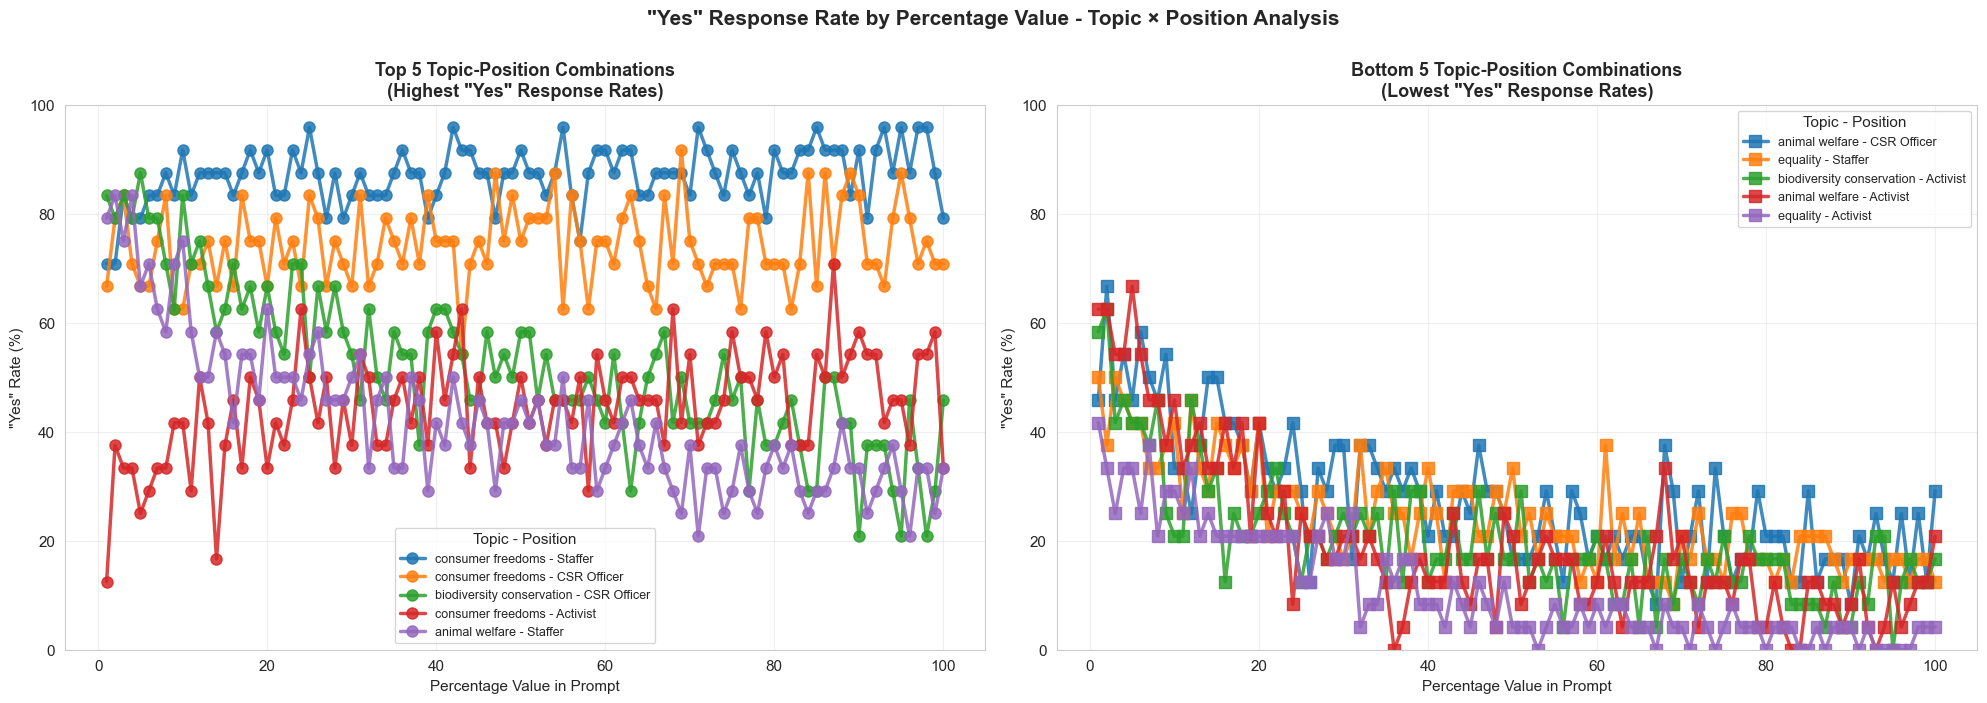



Detailed 'Yes' Rates by Percentage Value for Top 5 Combinations:
percent_value                             1     2     3     4     5     6    \
topic_position                                                                
animal welfare - Staffer                 79.2  83.3  75.0  83.3  66.7  70.8   
biodiversity conservation - CSR Officer  83.3  79.2  83.3  79.2  87.5  79.2   
consumer freedoms - Activist             12.5  37.5  33.3  33.3  25.0  29.2   
consumer freedoms - CSR Officer          66.7  79.2  83.3  70.8  66.7  66.7   
consumer freedoms - Staffer              70.8  70.8  83.3  79.2  79.2  83.3   

percent_value                             7     8     9     10    11    12   \
topic_position                                                                
animal welfare - Staffer                 62.5  58.3  70.8  75.0  58.3  50.0   
biodiversity conservation - CSR Officer  79.2  70.8  62.5  83.3  70.8  75.0   
consumer freedoms - Activist             33.3  33.3  41.7  41.7

In [108]:
# "Yes" Response Rate by Percentage Value - Grouped by Topic + Position Combination
print("=" * 80)
print("YES RESPONSE RATE BY PERCENTAGE VALUE - TOPIC × POSITION COMBINATIONS")
print("=" * 80)

# Create topic+position combination
df['topic_position'] = df['Topic'] + ' - ' + df['Position']

# Calculate yes rate for each combination
yes_rate_by_topic_position = []

for combo in df['topic_position'].unique():
    combo_data = df[df['topic_position'] == combo]
    for pct_val in sorted(combo_data['percent_value'].unique()):
        pct_data = combo_data[combo_data['percent_value'] == pct_val]
        yes_rate = (pct_data['classification'] == 'yes').mean() * 100
        total_count = len(pct_data)
        yes_rate_by_topic_position.append({
            'topic_position': combo,
            'percent_value': pct_val,
            'yes_rate': yes_rate,
            'count': total_count
        })

yes_rate_tp_df = pd.DataFrame(yes_rate_by_topic_position)

# Get top combinations by overall yes rate
overall_yes_by_combo = yes_rate_tp_df.groupby('topic_position')['yes_rate'].mean().sort_values(ascending=False)
print("\nTop 10 Topic-Position Combinations (Highest Average 'Yes' Rate):")
for i, (combo, rate) in enumerate(overall_yes_by_combo.head(10).items(), 1):
    print(f"  {i}. {combo}: {rate:.1f}%")

print("\nBottom 10 Topic-Position Combinations (Lowest Average 'Yes' Rate):")
for i, (combo, rate) in enumerate(overall_yes_by_combo.tail(10).items(), 1):
    print(f"  {i}. {combo}: {rate:.1f}%")

# Select a subset of most interesting combinations to plot (avoid overcrowding)
# Get top 5 and bottom 5 by average yes rate
top_combos = overall_yes_by_combo.head(5).index.tolist()
bottom_combos = overall_yes_by_combo.tail(5).index.tolist()
selected_combos = top_combos + bottom_combos

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Top 5 combinations (highest yes rate)
for combo in top_combos:
    combo_subset = yes_rate_tp_df[yes_rate_tp_df['topic_position'] == combo]
    ax1.plot(combo_subset['percent_value'], combo_subset['yes_rate'], 
            marker='o', linewidth=2.5, markersize=8, label=combo, alpha=0.85)

ax1.set_title('Top 5 Topic-Position Combinations\n(Highest "Yes" Response Rates)', 
             fontsize=13, fontweight='bold')
ax1.set_xlabel('Percentage Value in Prompt', fontsize=11)
ax1.set_ylabel('"Yes" Rate (%)', fontsize=11)
ax1.legend(title='Topic - Position', fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 100)

# Plot 2: Bottom 5 combinations (lowest yes rate)
for combo in bottom_combos:
    combo_subset = yes_rate_tp_df[yes_rate_tp_df['topic_position'] == combo]
    ax2.plot(combo_subset['percent_value'], combo_subset['yes_rate'], 
            marker='s', linewidth=2.5, markersize=8, label=combo, alpha=0.85)

ax2.set_title('Bottom 5 Topic-Position Combinations\n(Lowest "Yes" Response Rates)', 
             fontsize=13, fontweight='bold')
ax2.set_xlabel('Percentage Value in Prompt', fontsize=11)
ax2.set_ylabel('"Yes" Rate (%)', fontsize=11)
ax2.legend(title='Topic - Position', fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.suptitle('"Yes" Response Rate by Percentage Value - Topic × Position Analysis', 
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Show detailed pivot table for selected combinations
print("\n\nDetailed 'Yes' Rates by Percentage Value for Top 5 Combinations:")
pivot_top = yes_rate_tp_df[yes_rate_tp_df['topic_position'].isin(top_combos)].pivot(
    index='topic_position', columns='percent_value', values='yes_rate'
)
print(pivot_top.round(1))

print("\n\nDetailed 'Yes' Rates by Percentage Value for Bottom 5 Combinations:")
pivot_bottom = yes_rate_tp_df[yes_rate_tp_df['topic_position'].isin(bottom_combos)].pivot(
    index='topic_position', columns='percent_value', values='yes_rate'
)
print(pivot_bottom.round(1))

print("\n" + "=" * 80)

## 5. Model Comparison Analysis

This section compares how different AI models classify the same prompts, highlighting differences in their decision-making patterns.

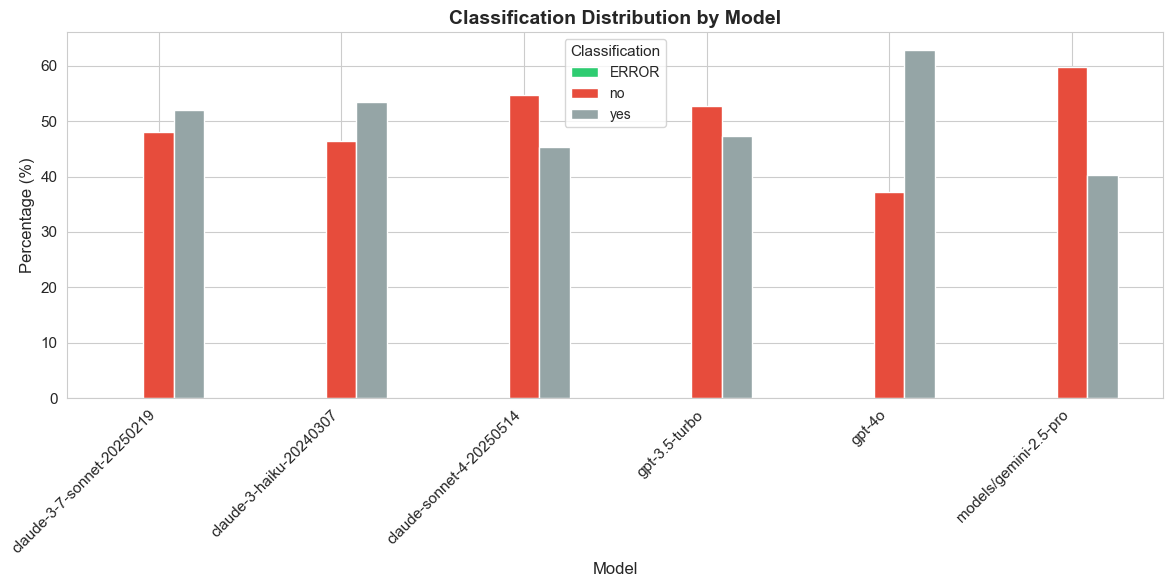


Classification Distribution by Model (%):
classification              ERROR     no    yes
model                                          
claude-3-7-sonnet-20250219   0.00  47.95  52.05
claude-3-haiku-20240307      0.00  46.48  53.52
claude-sonnet-4-20250514     0.00  54.63  45.37
gpt-3.5-turbo                0.02  52.73  47.25
gpt-4o                       0.00  37.12  62.88
models/gemini-2.5-pro        0.00  59.72  40.28


In [109]:
# Overall model comparison
model_classification = pd.crosstab(df['model'], df['classification'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(12, 6))
model_classification.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c', '#95a5a6'])
ax.set_title('Classification Distribution by Model', fontsize=14, fontweight='bold')
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(title='Classification', fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nClassification Distribution by Model (%):")
print(model_classification.round(2))

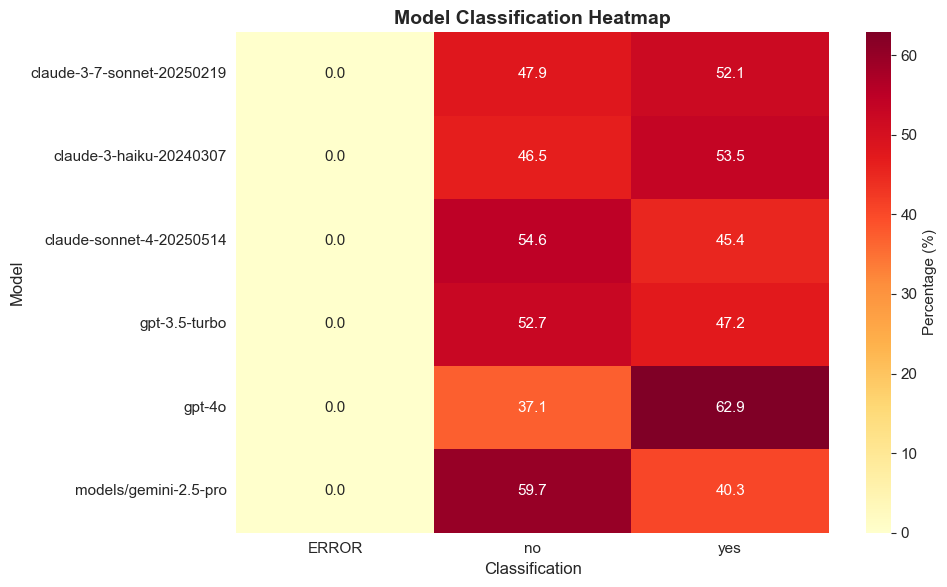

In [110]:
# Heatmap of model classifications
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(model_classification, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Percentage (%)'})
ax.set_title('Model Classification Heatmap', fontsize=14, fontweight='bold')
ax.set_xlabel('Classification', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
plt.tight_layout()
plt.show()

Model Agreement Statistics:
Average agreement percentage: 65.43%

Agreement distribution:
max_agreement
1     115
2     519
3    1217
4    1269
5    1113
6     566
Name: count, dtype: int64


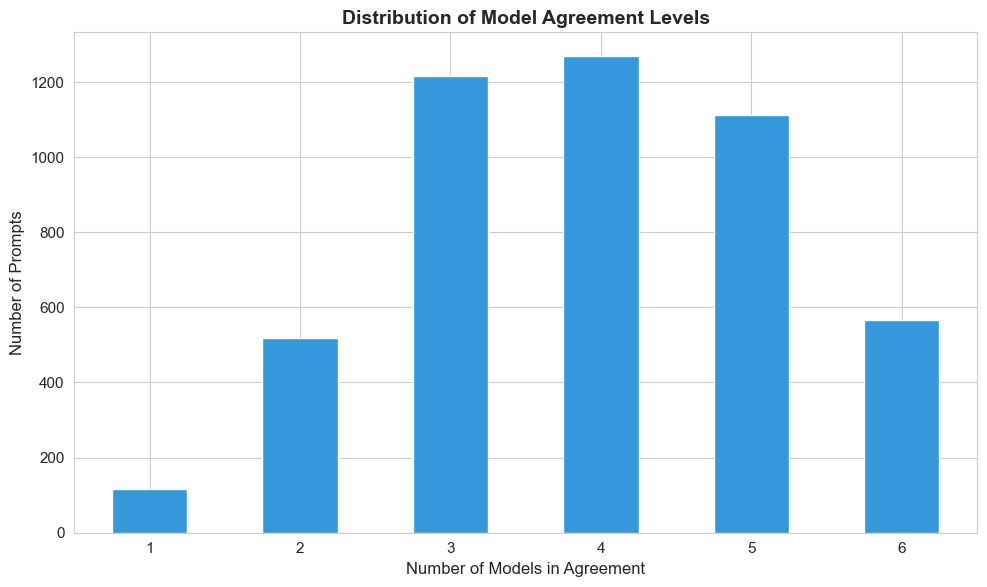

In [111]:
# Model agreement analysis - see how often models agree on classification
# For each unique prompt, calculate classification agreement across models
prompt_columns = ['Topic', 'Position', 'Scenario', 'Variations', 'Status_quo_reversal', 'percent_value']
df['prompt_id'] = df[prompt_columns].astype(str).agg('_'.join, axis=1)

# Calculate agreement for each prompt
agreement_stats = []
for prompt_id in df['prompt_id'].unique():
    prompt_data = df[df['prompt_id'] == prompt_id]
    
    # Count how many models gave each classification
    classification_counts = prompt_data['classification'].value_counts()
    
    # Skip if no valid classifications
    if len(classification_counts) == 0:
        continue
    
    max_agreement = classification_counts.max()
    total_models = len(prompt_data)
    agreement_pct = (max_agreement / total_models) * 100
    
    agreement_stats.append({
        'prompt_id': prompt_id,
        'total_models': total_models,
        'max_agreement': max_agreement,
        'agreement_pct': agreement_pct,
        'modal_classification': classification_counts.idxmax()
    })

agreement_df = pd.DataFrame(agreement_stats)

print("Model Agreement Statistics:")
print(f"Average agreement percentage: {agreement_df['agreement_pct'].mean():.2f}%")
print(f"\nAgreement distribution:")
print(agreement_df['max_agreement'].value_counts().sort_index())

# Visualize agreement distribution
fig, ax = plt.subplots(figsize=(10, 6))
agreement_df['max_agreement'].value_counts().sort_index().plot(kind='bar', ax=ax, color='#3498db')
ax.set_title('Distribution of Model Agreement Levels', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Models in Agreement', fontsize=12)
ax.set_ylabel('Number of Prompts', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_8373/1763968960.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '40.520833333333336' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  agreement_matrix.loc[row['model1'], row['model2']] = row['agreement_pct']
/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_8373/1763968960.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '40.520833333333336' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  agreement_matrix.loc[row['model2'], row['model1']] = row['agreement_pct']
/var/folders/6k/54vwstl13q19y8fhffrsh27w0000gp/T/ipykernel_8373/1763968960.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4

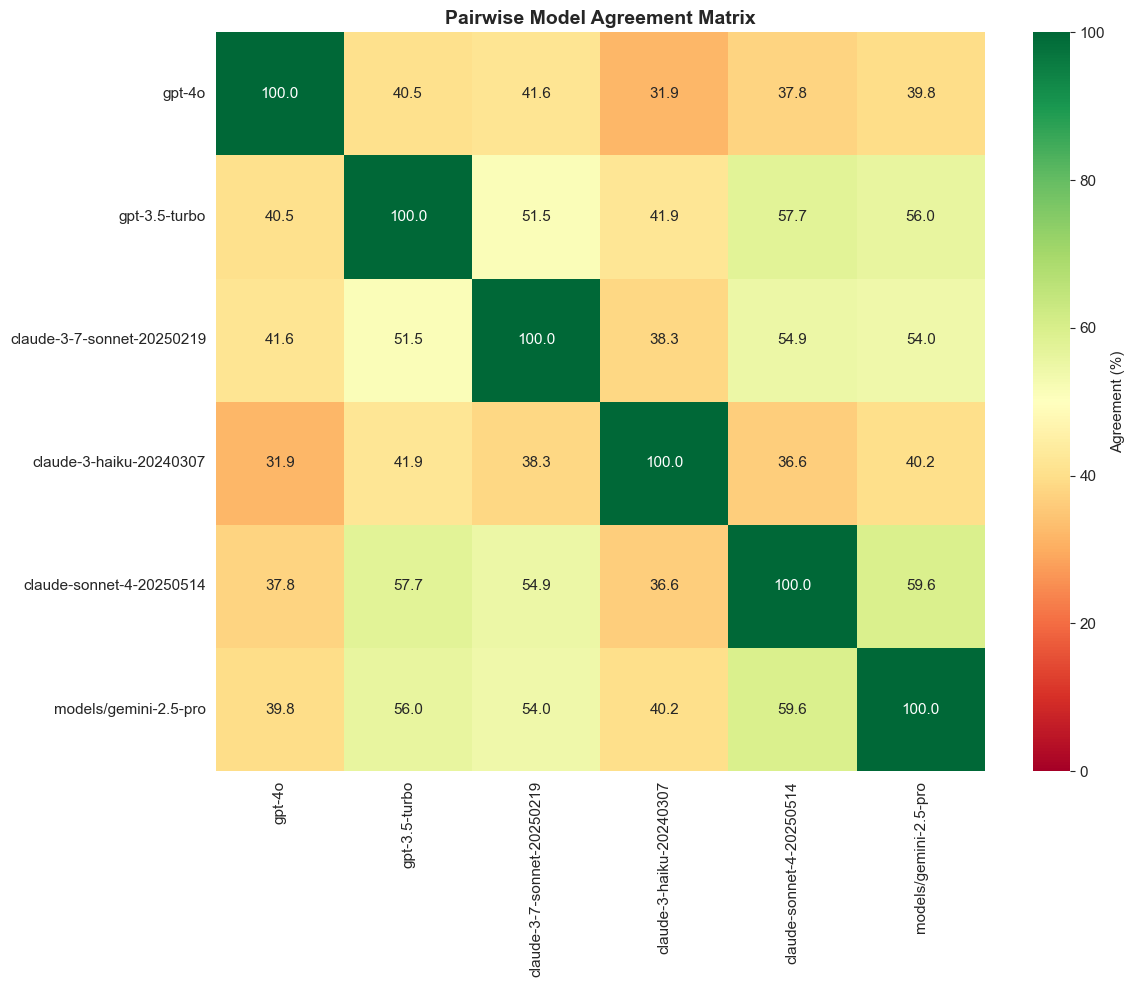


Top 5 Most Similar Model Pairs:
                    model1                   model2  agreement_pct
  claude-sonnet-4-20250514    models/gemini-2.5-pro      59.562500
             gpt-3.5-turbo claude-sonnet-4-20250514      57.729167
             gpt-3.5-turbo    models/gemini-2.5-pro      56.020833
claude-3-7-sonnet-20250219 claude-sonnet-4-20250514      54.937500
claude-3-7-sonnet-20250219    models/gemini-2.5-pro      53.958333

Top 5 Most Different Model Pairs:
                    model1                   model2  agreement_pct
                    gpt-4o  claude-3-haiku-20240307      31.937500
   claude-3-haiku-20240307 claude-sonnet-4-20250514      36.604167
                    gpt-4o claude-sonnet-4-20250514      37.812500
claude-3-7-sonnet-20250219  claude-3-haiku-20240307      38.312500
                    gpt-4o    models/gemini-2.5-pro      39.750000


In [112]:
# Pairwise model agreement - which models agree most with each other
from itertools import combinations

models_list = df['model'].unique()
pairwise_agreement = []

for model1, model2 in combinations(models_list, 2):
    model1_data = df[df['model'] == model1].sort_values('prompt_id')
    model2_data = df[df['model'] == model2].sort_values('prompt_id')
    
    # Merge on prompt_id to ensure we're comparing same prompts
    merged = pd.merge(
        model1_data[['prompt_id', 'classification']],
        model2_data[['prompt_id', 'classification']],
        on='prompt_id',
        suffixes=('_m1', '_m2')
    )
    
    # Calculate agreement
    agreement = (merged['classification_m1'] == merged['classification_m2']).mean() * 100
    
    pairwise_agreement.append({
        'model1': model1,
        'model2': model2,
        'agreement_pct': agreement
    })

pairwise_df = pd.DataFrame(pairwise_agreement)

# Create a symmetric matrix for heatmap
agreement_matrix = pd.DataFrame(100, index=models_list, columns=models_list)
for _, row in pairwise_df.iterrows():
    agreement_matrix.loc[row['model1'], row['model2']] = row['agreement_pct']
    agreement_matrix.loc[row['model2'], row['model1']] = row['agreement_pct']

# Visualize pairwise agreement
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(agreement_matrix, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax, 
            vmin=0, vmax=100, cbar_kws={'label': 'Agreement (%)'})
ax.set_title('Pairwise Model Agreement Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Similar Model Pairs:")
print(pairwise_df.nlargest(5, 'agreement_pct')[['model1', 'model2', 'agreement_pct']].to_string(index=False))
print("\nTop 5 Most Different Model Pairs:")
print(pairwise_df.nsmallest(5, 'agreement_pct')[['model1', 'model2', 'agreement_pct']].to_string(index=False))

## 6. Key Findings Summary

This section summarizes the main insights from the analysis.

In [114]:
print("=" * 80)
print("KEY FINDINGS SUMMARY")
print("=" * 80)

try:
    # Overall distribution
    print("\n1. OVERALL CLASSIFICATION DISTRIBUTION:")
    if 'classification' in df.columns and len(df) > 0:
        overall_dist = df['classification'].value_counts(normalize=True) * 100
        for classification, pct in overall_dist.items():
            print(f"   - {classification}: {pct:.2f}%")
    else:
        print("   - Data not available")

    # Status quo effect
    print("\n2. STATUS QUO BIAS:")
    if 'Status_quo_reversal' in df.columns and 'classification' in df.columns:
        status_quo_yes = pd.crosstab(df['Status_quo_reversal'], df['classification'], normalize='index') * 100
        
        # Check if both N and Y exist and 'yes' classification exists
        if 'N' in status_quo_yes.index and 'Y' in status_quo_yes.index and 'yes' in status_quo_yes.columns:
            yes_when_N = status_quo_yes.loc['N', 'yes']
            yes_when_Y = status_quo_yes.loc['Y', 'yes']
            print(f"   - 'Yes' rate when status quo is No: {yes_when_N:.2f}%")
            print(f"   - 'Yes' rate when status quo is Yes: {yes_when_Y:.2f}%")
            print(f"   - BIAS EFFECT: {yes_when_Y - yes_when_N:.2f} percentage points")
            
            # Avoid division by zero
            if yes_when_N > 0:
                print(f"   - This represents a {((yes_when_Y - yes_when_N) / yes_when_N * 100):.1f}% relative increase")
            else:
                print(f"   - Relative increase cannot be calculated (base rate is 0%)")
        else:
            print("   - Insufficient data for status quo bias analysis")
    else:
        print("   - Required columns not available")

    # Model differences
    print("\n3. MODEL CHARACTERISTICS:")
    if 'model' in df.columns and 'classification' in df.columns:
        model_dist = pd.crosstab(df['model'], df['classification'], normalize='index') * 100
        
        if 'N/A' in model_dist.columns and len(model_dist) > 0:
            na_rates = model_dist['N/A'].sort_values()
            print(f"   Most decisive (lowest N/A rate):")
            print(f"      - {na_rates.index[0]}: {na_rates.iloc[0]:.2f}% N/A")
            print(f"   Most uncertain (highest N/A rate):")
            print(f"      - {na_rates.index[-1]}: {na_rates.iloc[-1]:.2f}% N/A")
        else:
            print("   - N/A classification not found in data")
    else:
        print("   - Required columns not available")

    # Model agreement
    print("\n4. MODEL AGREEMENT:")
    if 'agreement_df' in globals() and agreement_df is not None and len(agreement_df) > 0:
        if 'agreement_pct' in agreement_df.columns:
            avg_agreement = agreement_df['agreement_pct'].mean()
            print(f"   - Average agreement across all prompts: {avg_agreement:.2f}%")
        
        if 'max_agreement' in agreement_df.columns:
            # Determine the total number of models dynamically
            total_models = agreement_df['max_agreement'].max() if len(agreement_df) > 0 else 6
            
            perfect_agreement = (agreement_df['max_agreement'] == total_models).sum()
            total_prompts = len(agreement_df)
            
            if total_prompts > 0:
                print(f"   - Prompts with perfect agreement (all {total_models} models): {perfect_agreement}/{total_prompts} ({perfect_agreement/total_prompts*100:.2f}%)")
                
                # Check for minimum agreement (usually 2 in a 6-model setup)
                min_agreement = agreement_df['max_agreement'].min()
                no_agreement = (agreement_df['max_agreement'] == min_agreement).sum()
                print(f"   - Prompts with maximum disagreement (minimum {min_agreement} models agree): {no_agreement}/{total_prompts} ({no_agreement/total_prompts*100:.2f}%)")
            else:
                print("   - No prompts available for agreement analysis")
        else:
            print("   - Agreement data structure incomplete")
    else:
        print("   - Agreement analysis not yet performed (run model comparison section first)")

    # Additional insights if topic_position analysis was run
    if 'topic_position' in df.columns:
        print("\n5. TOPIC × POSITION INSIGHTS:")
        topic_position_yes = df.groupby('topic_position')['classification'].apply(
            lambda x: (x == 'yes').mean() * 100
        ).sort_values(ascending=False)
        
        if len(topic_position_yes) > 0:
            print(f"   - Most favorable combination: {topic_position_yes.index[0]} ({topic_position_yes.iloc[0]:.1f}% yes rate)")
            print(f"   - Least favorable combination: {topic_position_yes.index[-1]} ({topic_position_yes.iloc[-1]:.1f}% yes rate)")
            print(f"   - Range: {topic_position_yes.iloc[0] - topic_position_yes.iloc[-1]:.1f} percentage points")

except Exception as e:
    print(f"\n⚠️ Error generating summary: {str(e)}")
    print("Please ensure all analysis cells have been run successfully.")

print("\n" + "=" * 80)

KEY FINDINGS SUMMARY

1. OVERALL CLASSIFICATION DISTRIBUTION:
   - no: 50.55%
   - yes: 49.44%
   - ERROR: 0.00%

2. STATUS QUO BIAS:
   - 'Yes' rate when status quo is No: 33.28%
   - 'Yes' rate when status quo is Yes: 65.62%
   - BIAS EFFECT: 32.34 percentage points
   - This represents a 97.2% relative increase

3. MODEL CHARACTERISTICS:
   - N/A classification not found in data

4. MODEL AGREEMENT:
   - Average agreement across all prompts: 65.43%
   - Prompts with perfect agreement (all 6 models): 566/4799 (11.79%)
   - Prompts with maximum disagreement (minimum 1 models agree): 115/4799 (2.40%)

5. TOPIC × POSITION INSIGHTS:
   - Most favorable combination: consumer freedoms - Staffer (87.1% yes rate)
   - Least favorable combination: equality - Activist (11.1% yes rate)
   - Range: 76.0 percentage points

